# Prophet Demand Forecasting Tuning

This workflow loads the daily demand series, tunes Prophet hyperparameters across five configurations, evaluates each model on a holdout period, selects the best performer, and exports the best forecast.

In [58]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

warnings.filterwarnings("ignore")

print("Prophet tuning workflow initialized")

Prophet tuning workflow initialized


In [59]:
DATA_PATH = Path("../data/dataset_2_daily_demand_forecasting.csv.csv")
OUTPUT_PATH = Path("../outputs/demand_forecast.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(DATA_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="coerce")
raw_df = raw_df.dropna(subset=["Date"]).sort_values("Date")

series_df = (
    raw_df[["Date", "Total_Quantity"]]
    .rename(columns={"Date": "ds", "Total_Quantity": "y"})
    .set_index("ds")
    .resample("D")
    .sum()
    .reset_index()
)
series_df["y"] = series_df["y"].fillna(0).astype(float)
series_df = series_df.sort_values("ds").reset_index(drop=True)

series_df.head()

,ds,y
0,2009-12-01,26098.0
1,2009-12-02,31804.0
2,2009-12-03,49221.0
3,2009-12-04,21210.0
4,2009-12-05,5119.0


In [60]:
series_df.info()
series_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 739 entries, 0 to 738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      739 non-null    datetime64[us]
 1   y       739 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.7 KB


,ds,y
count,739,739.000000
mean,2010-12-05 00:00:00,15162.581867
min,2009-12-01 00:00:00,0.000000
25%,2010-06-03 12:00:00,8122.500000
50%,2010-12-05 00:00:00,13980.000000
75%,2011-06-07 12:00:00,20499.000000
max,2011-12-09 00:00:00,125489.000000
std,NaN,13037.040684


In [61]:
def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calculate MAE, RMSE, and MAPE for a forecast."""
    mask = y_true != 0
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return {"mae": float(mae), "rmse": rmse, "mape": mape}


n_test = max(30, int(len(series_df) * 0.2))
split_index = len(series_df) - n_test
train = series_df.iloc[:split_index].copy()
test = series_df.iloc[split_index:].copy()

print(f"Training rows: {len(train)}")
print(f"Test rows: {len(test)}")

Training rows: 592
Test rows: 147


In [62]:
from prophet import Prophet
import pandas as pd
import numpy as np

In [63]:
test_metrics = calculate_metrics(
    evaluation_df["y"].to_numpy(),
    evaluation_df["yhat"].to_numpy()
)

print(test_metrics)

{'mae': 6926.527541737286, 'rmse': 10304.591897235587, 'mape': 33.823301141078986}


In [64]:
model_configs = [
    {"name": "baseline", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0},
    {"name": "flexible", "changepoint_prior_scale": 0.10, "seasonality_prior_scale": 10.0},
    {"name": "smooth", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 20.0},
    {"name": "aggressive", "changepoint_prior_scale": 0.20, "seasonality_prior_scale": 15.0},
    {"name": "balanced", "changepoint_prior_scale": 0.08, "seasonality_prior_scale": 12.0},
]

results = []

for config in model_configs:
    model = Prophet(
        changepoint_prior_scale=config["changepoint_prior_scale"],
        seasonality_prior_scale=config["seasonality_prior_scale"],
        yearly_seasonality=True,
        weekly_seasonality=True,
        interval_width=0.95,
    )

    model.add_seasonality(
        name="monthly",
        period=30.5,
        fourier_order=5,
    )

    model.fit(train)

    future = model.make_future_dataframe(periods=len(test), freq="D")
    forecast = model.predict(future)

    evaluation_df = test.merge(
        forecast[["ds", "yhat"]],
        on="ds",
        how="inner"
    )

    metrics = calculate_metrics(
        evaluation_df["y"].to_numpy(),
        evaluation_df["yhat"].to_numpy()
    )

    row = {
        "model": config["name"],
        "changepoint_prior_scale": config["changepoint_prior_scale"],
        "seasonality_prior_scale": config["seasonality_prior_scale"],
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
    }

    results.append(row)

    print(
        f"{config['name']} --> "
        f"MAE: {metrics['mae']:.2f}, "
        f"RMSE: {metrics['rmse']:.2f}, "
        f"MAPE: {metrics['mape']:.2f}%"
    )

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(["mape", "rmse", "mae"], ascending=[True, True, True]).reset_index(drop=True)
comparison_df

16:03:34 - cmdstanpy - INFO - Chain [1] start processing
16:03:34 - cmdstanpy - INFO - Chain [1] done processing


baseline --> MAE: 6939.38, RMSE: 10325.50, MAPE: 33.81%


16:03:34 - cmdstanpy - INFO - Chain [1] start processing
16:03:34 - cmdstanpy - INFO - Chain [1] done processing


flexible --> MAE: 6931.52, RMSE: 10315.30, MAPE: 33.83%


16:03:35 - cmdstanpy - INFO - Chain [1] start processing
16:03:35 - cmdstanpy - INFO - Chain [1] done processing
16:03:35 - cmdstanpy - INFO - Chain [1] start processing


...

16:03:35 - cmdstanpy - INFO - Chain [1] done processing
16:03:36 - cmdstanpy - INFO - Chain [1] start processing


aggressive --> MAE: 6816.94, RMSE: 10022.51, MAPE: 34.64%


16:03:36 - cmdstanpy - INFO - Chain [1] done processing


balanced --> MAE: 6926.53, RMSE: 10304.59, MAPE: 33.82%


,model,changepoint_prior_scale,seasonality_prior_scale,mae,rmse,mape
0,baseline,0.05,10.0,6939.375394,10325.500990,33.811195
1,smooth,0.05,20.0,6945.991867,10337.275726,33.817158
2,balanced,0.08,12.0,6926.527542,10304.591897,33.823301
3,flexible,0.10,10.0,6931.516467,10315.297927,33.830511
4,aggressive,0.20,15.0,6816.936702,10022.509753,34.635579


In [65]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(["mape", "rmse", "mae"], ascending=[True, True, True]).reset_index(drop=True)
comparison_df

,model,changepoint_prior_scale,seasonality_prior_scale,mae,rmse,mape
0,baseline,0.05,10.0,6939.375394,10325.500990,33.811195
1,smooth,0.05,20.0,6945.991867,10337.275726,33.817158
2,balanced,0.08,12.0,6926.527542,10304.591897,33.823301
3,flexible,0.10,10.0,6931.516467,10315.297927,33.830511
4,aggressive,0.20,15.0,6816.936702,10022.509753,34.635579


In [66]:
best_config = comparison_df.iloc[0].to_dict()
best_model_name = best_config["model"]

print(f"Best model: {best_model_name}")
print(f"MAE: {best_config['mae']:.2f}")
print(f"RMSE: {best_config['rmse']:.2f}")
print(f"MAPE: {best_config['mape']:.2f}%")

best_model = Prophet(
    changepoint_prior_scale=best_config["changepoint_prior_scale"],
    seasonality_prior_scale=best_config["seasonality_prior_scale"],
    yearly_seasonality=True,
    weekly_seasonality=True,
    interval_width=0.95,
)
best_model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)
best_model.fit(series_df)

future = best_model.make_future_dataframe(periods=30, freq="D")
best_forecast = best_model.predict(future)

best_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

Best model: baseline
MAE: 6939.38
RMSE: 10325.50
MAPE: 33.81%


16:03:36 - cmdstanpy - INFO - Chain [1] start processing
16:03:36 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
764,2012-01-04,11179.805039,-7611.357800,30450.638138
765,2012-01-05,15555.072580,-2344.944534,33664.889497
766,2012-01-06,10120.855111,-9230.907662,26935.734845
767,2012-01-07,-4691.359323,-23569.611659,14023.803414
768,2012-01-08,6768.848593,-9788.866066,25523.774237


In [67]:
best_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(OUTPUT_PATH, index=False)
print(f"Best forecast saved to {OUTPUT_PATH}")

Best forecast saved to ..\outputs\demand_forecast.csv


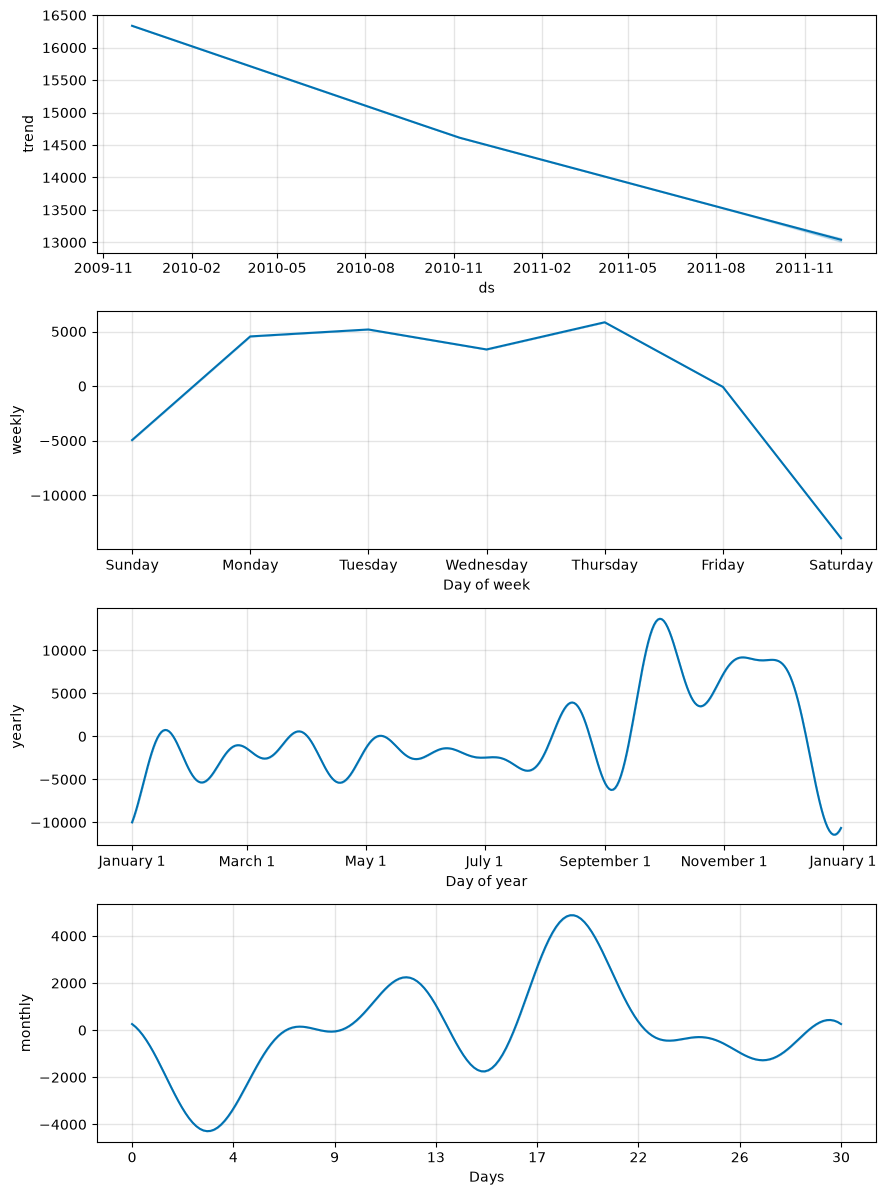

In [68]:
fig2 = model.plot_components(forecast)

In [69]:
print(test.head())

            ds        y
592 2011-07-16      0.0
593 2011-07-17  11019.0
594 2011-07-18  15098.0
595 2011-07-19  29168.0
596 2011-07-20  17676.0


In [70]:
print(forecast[['ds','yhat']].head())

          ds          yhat
0 2009-12-01  26839.785754
1 2009-12-02  26545.243962
2 2009-12-03  29922.161352
3 2009-12-04  23794.821273
4 2009-12-05   9252.704173


In [71]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mape = mean_absolute_percentage_error(
    y_true,
    y_pred
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 3.970951245115525e+20 %


In [72]:
print((test['y'] == 0).sum())
print(test['y'].min())

22
0.0


In [73]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mask = y_true != 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_pred[mask])
        / y_true[mask]
    )
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 33.82 %


In [74]:
df = pd.read_csv("../data/dataset_2_daily_demand_forecasting.csv.csv")

In [75]:
print(df.columns.tolist())

['Date', 'Total_Quantity', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Year', 'Month', 'Week_Of_Year', 'Day_Of_Week', 'Is_Weekend']


In [76]:
ts = df[["Date", "Total_Quantity"]].copy()

ts["Date"] = pd.to_datetime(ts["Date"])

ts.rename(
    columns={
        "Date": "ds",
        "Total_Quantity": "y"
    },
    inplace=True
)

ts = ts.sort_values("ds").reset_index(drop=True)

ts.head()

,ds,y
0,2009-12-01,26098.0
1,2009-12-02,31804.0
2,2009-12-03,49221.0
3,2009-12-04,21210.0
4,2009-12-05,5119.0


In [77]:
print(ts.head())

print(ts.columns)

print(ts.shape)

          ds        y
0 2009-12-01  26098.0
1 2009-12-02  31804.0
2 2009-12-03  49221.0
3 2009-12-04  21210.0
4 2009-12-05   5119.0
Index(['ds', 'y'], dtype='str')
(739, 2)


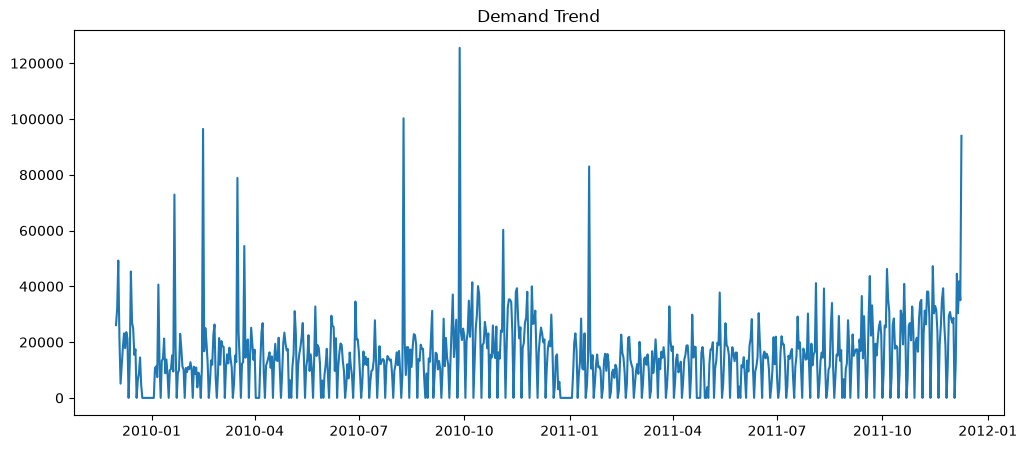

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts['ds'], ts['y'])
plt.title("Demand Trend")
plt.show()

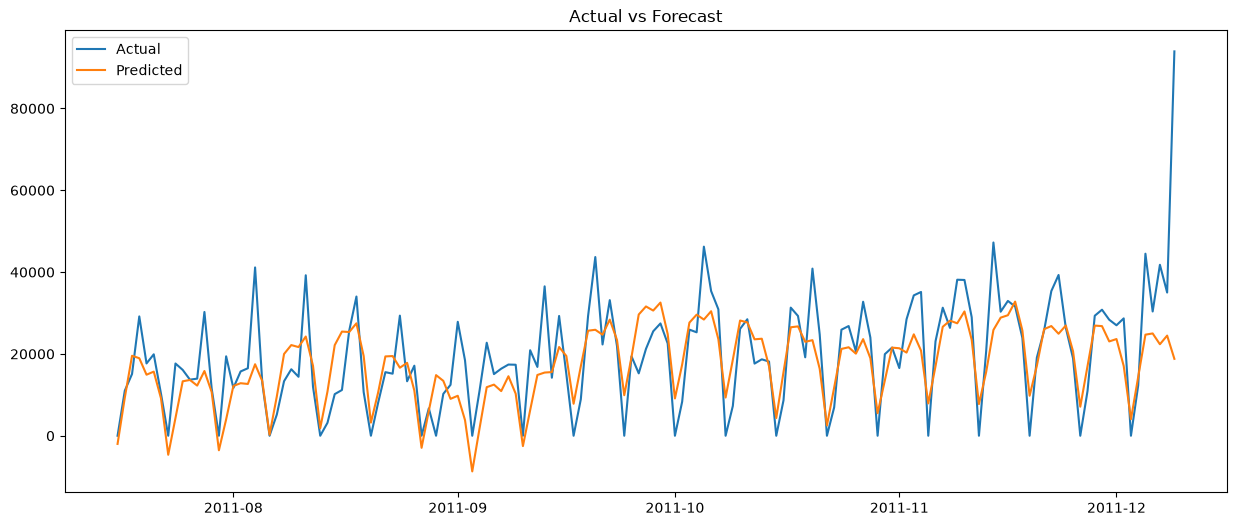

In [79]:
forecast_test = forecast.tail(len(test))

plt.figure(figsize=(15,6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Forecast")

plt.show()

In [80]:
ts["y"].describe()

count       739.000000
mean      15162.581867
std       13037.040684
min           0.000000
25%        8122.500000
50%       13980.000000
75%       20499.000000
max      125489.000000
Name: y, dtype: float64

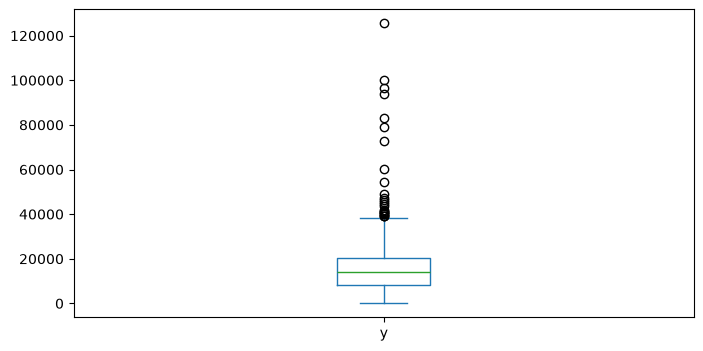

In [81]:
ts["y"].plot(
    kind="box",
    figsize=(8,4)
)
plt.show()

In [82]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mask = y_true != 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_pred[mask])
        / y_true[mask]
    )
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 33.82 %


In [83]:
actual = evaluation_df["y"]
predicted = evaluation_df["yhat"]

In [84]:
print(len(actual))
print(len(predicted))

print(actual.head())
print(predicted.head())

147
147
0        0.0
1    11019.0
2    15098.0
3    29168.0
4    17676.0
Name: y, dtype: float64
0    -1997.776777
1     9313.177944
2    19550.729041
3    18953.224145
4    14921.946687
Name: yhat, dtype: float64


In [85]:
print(type(actual))
print(type(predicted))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [86]:
print(actual[:10])
print(predicted[:10])

0        0.0
1    11019.0
2    15098.0
3    29168.0
4    17676.0
5    19907.0
6    10270.0
7        0.0
8    17661.0
9    16095.0
Name: y, dtype: float64
0    -1997.776777
1     9313.177944
2    19550.729041
3    18953.224145
4    14921.946687
5    15671.895245
6     9140.623773
7    -4646.552082
8     4271.480304
9    13311.069027
Name: yhat, dtype: float64


In [87]:
print("Actual Min:", actual.min())
print("Actual Max:", actual.max())

print("Predicted Min:", predicted.min())
print("Predicted Max:", predicted.max())

Actual Min: 0.0
Actual Max: 93950.0
Predicted Min: -8710.474692757873
Predicted Max: 32792.53661209233


In [88]:
print("Zero values in actual:")
print((actual == 0).sum())

Zero values in actual:
22


In [89]:
non_zero_mask = actual != 0

actual_non_zero = actual[non_zero_mask]
predicted_non_zero = predicted[non_zero_mask]

mape = np.mean(
    np.abs(
        (actual_non_zero - predicted_non_zero)
        / actual_non_zero
    )
) * 100

print(f"Corrected MAPE : {mape:.2f}%")

Corrected MAPE : 33.82%


In [90]:
forecast_output = pd.DataFrame({
    "Date": test["ds"].values,
    "Actual": actual,
    "Predicted": predicted
})

forecast_output.to_csv(
    "../outputs/demand_forecast.csv",
    index=False
)

print("Forecast exported successfully")

Forecast exported successfully


In [91]:
print(type(actual))
print(type(predicted))

print("Actual Min:", actual.min())
print("Actual Max:", actual.max())

print("Predicted Min:", predicted.min())
print("Predicted Max:", predicted.max())

print((actual == 0).sum())

<class 'pandas.Series'>
<class 'pandas.Series'>
Actual Min: 0.0
Actual Max: 93950.0
Predicted Min: -8710.474692757873
Predicted Max: 32792.53661209233
22


In [92]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,26839.785754,7454.737662,44128.776281
1,2009-12-02,26545.243962,8899.096110,43941.986749
2,2009-12-03,29922.161352,11844.217997,48509.648684
3,2009-12-04,23794.821273,5191.954098,42206.588258
4,2009-12-05,9252.704173,-9152.370546,28767.677512


In [93]:
forecast_output = forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
]

forecast_output.to_csv(
    '../outputs/demand_forecast.csv',
    index=False
)

print("Forecast Exported")

Forecast Exported


# RetailPulse Demand Forecasting

## Dataset Loading

## Data Cleaning

## Exploratory Data Analysis

## Time Series Preparation

## Trend Analysis

## Prophet Forecasting

## Forecast Evaluation

## Forecast Export

## Inventory Recommendations